# Ejemplos de codigo - Adult

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro




In [3]:
sns.set_theme(style="whitegrid")


In [4]:
# Cargar datos
data = pd.read_csv("adult.csv", na_values="?") # Se incluye na_values para marcar "?" como faltante

In [5]:
# 1) Informacion basica (filas, columnas)
data.shape

(48842, 15)

In [6]:
# 2) Revision inicial
data.head()


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income_status
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [7]:
# 3a) Tipos de datos
data.dtypes

# Tipos de datos a ver en pandas:
# - object/str: para variables categoricas o de texto (ojo que tambien pueden ser cosas como fechas o numeros con datos mal formateados)
# - categorical: para variables categoricas con un numero limitado de categorias (normalmente esto lo definen uds mismos al convertir una variable a este tipo, no es algo que venga por defecto)
# - int: Numeros enteros
# - float: Numeros con decimales
# - date/datetime: para fechas y horas (aunque a veces pueden estar como object si no se han parseado correctamente)
# - boolean: para variables que solo tienen dos categorias (True/False)

# NOTA: Ojo que no siempre los tipos de datos estan alineados con la esencia de la variable, 
# por ejemplo, "education-num" es un entero pero representa un ordinal (nivel educativo como número con orden)
# por lo que se podria convertir a factor (en R) o a categoria (en Python). Por esto es importante
# revisar: 
# 1) la documentacion del dataset si es que existe, y
# 2) inspeccionar cada variable a detalle para entender su naturaleza y decidir el tipo de dato mas adecuado para cada una.

age               int64
workclass           str
fnlwgt            int64
education           str
education-num     int64
marital-status      str
occupation          str
relationship        str
race                str
sex                 str
capital-gain      int64
capital-loss      int64
hours-per-week    int64
native-country      str
income_status       str
dtype: object

In [8]:
# 3b) Nos aseguramos que education-num se trate como categorica (aunque es un numero, representa niveles educativos con orden)
data["education-num"] = data["education-num"].astype("category")

In [9]:
# 3c) Variables de trabajo (detectadas automaticamente por tipo)
vars_categoricas = data.select_dtypes(include=["object", "category", "bool", "string"]).columns.tolist()
vars_numericas = data.select_dtypes(include=[np.number]).columns.tolist()
print("Variables categóricas:", vars_categoricas)
print("Variables numéricas:", vars_numericas)

Variables categóricas: ['workclass', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'income_status']
Variables numéricas: ['age', 'fnlwgt', 'capital-gain', 'capital-loss', 'hours-per-week']


In [10]:
# 4) Descripcion de variables y observaciones
data.describe(include="all")


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income_status
count,48842.000000,46043,4.884200e+04,48842,48842.0,48842,46033,48842,48842,48842,48842.000000,48842.000000,48842.000000,47985,48842
unique,NaN,8,NaN,16,16.0,7,14,6,5,2,NaN,NaN,NaN,41,4
top,NaN,Private,NaN,HS-grad,9.0,Married-civ-spouse,Prof-specialty,Husband,White,Male,NaN,NaN,NaN,United-States,<=50K
freq,NaN,33906,NaN,15784,15784.0,22379,6172,19716,41762,32650,NaN,NaN,NaN,43832,24720
mean,38.643585,NaN,1.896641e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1079.067626,87.502314,40.422382,NaN,NaN
std,13.710510,NaN,1.056040e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7452.019058,403.004552,12.391444,NaN,NaN
min,17.000000,NaN,1.228500e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,1.000000,NaN,NaN
25%,28.000000,NaN,1.175505e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
50%,37.000000,NaN,1.781445e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
75%,48.000000,NaN,2.376420e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,45.000000,NaN,NaN


In [11]:
# 4b) Unicos por variable
for var in vars_categoricas:
    print(f"Variable: {var}")
    print(list(data[var].unique()))

Variable: workclass
['State-gov', 'Self-emp-not-inc', 'Private', 'Federal-gov', 'Local-gov', nan, 'Self-emp-inc', 'Without-pay', 'Never-worked']
Variable: education
['Bachelors', 'HS-grad', '11th', 'Masters', '9th', 'Some-college', 'Assoc-acdm', 'Assoc-voc', '7th-8th', 'Doctorate', 'Prof-school', '5th-6th', '10th', '1st-4th', 'Preschool', '12th']
Variable: education-num
[13, 9, 7, 14, 5, 10, 12, 11, 4, 16, 15, 3, 6, 2, 1, 8]
Variable: marital-status
['Never-married', 'Married-civ-spouse', 'Divorced', 'Married-spouse-absent', 'Separated', 'Married-AF-spouse', 'Widowed']
Variable: occupation
['Adm-clerical', 'Exec-managerial', 'Handlers-cleaners', 'Prof-specialty', 'Other-service', 'Sales', 'Craft-repair', 'Transport-moving', 'Farming-fishing', 'Machine-op-inspct', 'Tech-support', nan, 'Protective-serv', 'Armed-Forces', 'Priv-house-serv']
Variable: relationship
['Not-in-family', 'Husband', 'Wife', 'Own-child', 'Unmarried', 'Other-relative']
Variable: race
['White', 'Black', 'Asian-Pac-Is

In [12]:
# 5a) Conteos por variable categorica (para una sola variable, workclass)
data["workclass"].value_counts(dropna=False)

workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
NaN                  2799
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

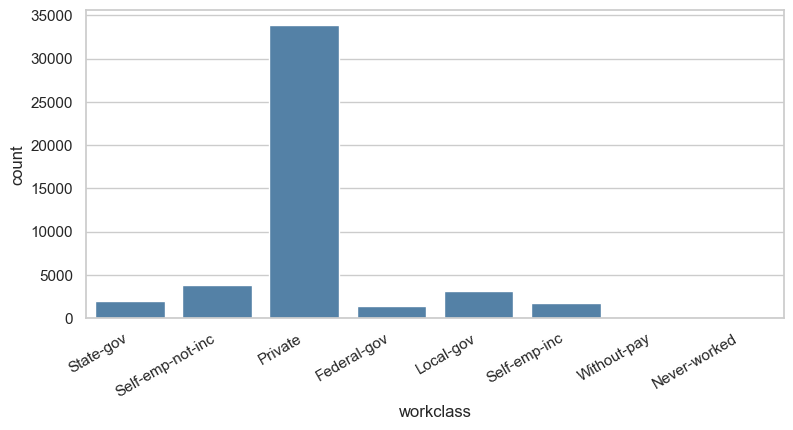

In [13]:
# 5b) Grafico de barras (categorica)
plt.figure(figsize=(9, 4))
sns.countplot(data=data, x="workclass", color="steelblue")
plt.xticks(rotation=30, ha="right")
plt.show()


In [14]:
# 6) Tabla de medidas numericas
data[vars_numericas].describe().T


,count,mean,std,min,25%,50%,75%,max
age,48842.0,38.643585,13.710510,17.0,28.0,37.0,48.0,90.0
fnlwgt,48842.0,189664.134597,105604.025423,12285.0,117550.5,178144.5,237642.0,1490400.0
capital-gain,48842.0,1079.067626,7452.019058,0.0,0.0,0.0,0.0,99999.0
capital-loss,48842.0,87.502314,403.004552,0.0,0.0,0.0,0.0,4356.0
hours-per-week,48842.0,40.422382,12.391444,1.0,40.0,40.0,45.0,99.0


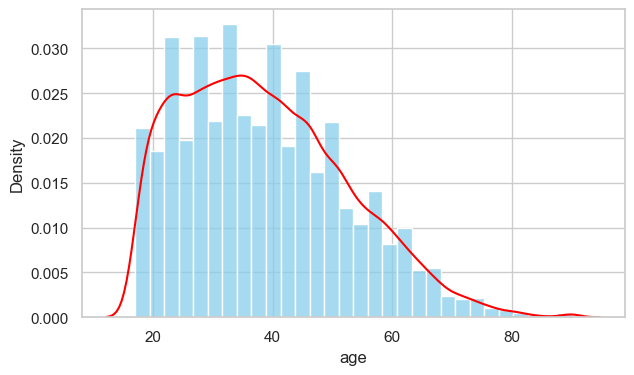

In [16]:
# 7) Histograma + densidad
plt.figure(figsize=(7, 4))
sns.histplot(data=data, x="age", bins=30, stat="density", color="skyblue")
sns.kdeplot(data=data, x="age", color="red")
plt.show()


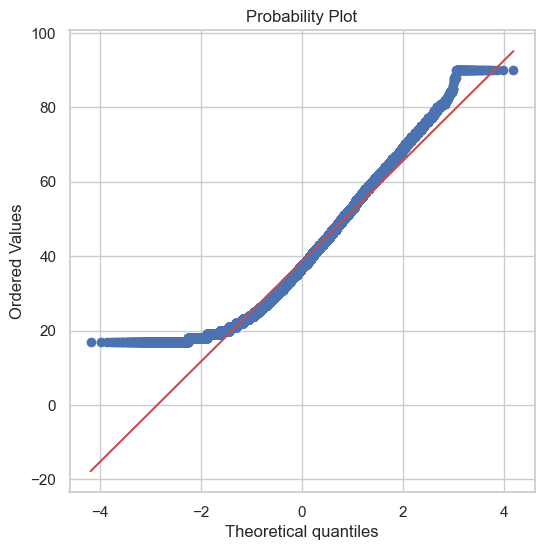

In [17]:
# 8a) Q-Q plot
import scipy.stats as stats
plt.figure(figsize=(6, 6))
stats.probplot(data["age"].dropna(), dist="norm", plot=plt)
plt.show()


In [18]:
# 8b) Prueba Shapiro (muestra para mantener simple)
np.random.seed(123)
age_sample = data["age"].dropna().sample(n=min(5000, data["age"].dropna().shape[0]), random_state=123)
shapiro(age_sample)


ShapiroResult(statistic=np.float64(0.962582544917251), pvalue=np.float64(4.168140842499828e-34))

Se rechaza nomalidad cuando el p-value es menor al threshold (comúnmente 0.05), lo que indica que la distribución de la variable se desvía significativamente de una distribución normal. Sin embargo, en datasets grandes, incluso pequeñas desviaciones de la normalidad pueden resultar en un p-value significativo, por lo que es importante complementar el análisis con gráficos (como histogramas o Q-Q plots) y medidas de asimetría y curtosis para obtener una comprensión más completa de la distribución de la variable.

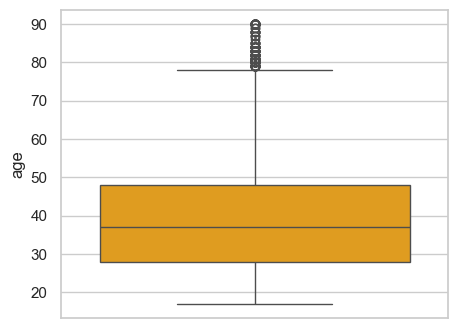

In [19]:
# 9) Boxplot de atipicos
plt.figure(figsize=(5, 4))
sns.boxplot(y=data["age"], color="orange")
plt.show()


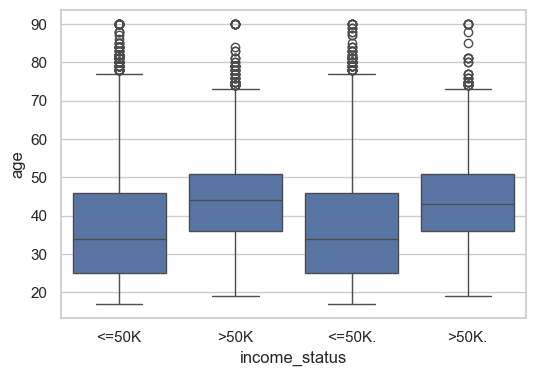

In [20]:
# 10) Numerica vs categorica (boxplot)
plt.figure(figsize=(6, 4))
sns.boxplot(data=data, x="income_status", y="age")
plt.show()


In [21]:
# 11) Faltantes por columna (tabla)
# NOTA: Este dataset no tiene faltantes, pero se muestra el codigo para que lo puedan usar en otros casos
data.isna().sum()

age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
income_status        0
dtype: int64

In [22]:
# 11a) Faltantes por columna (tabla con porcentajes, sacar el 100* para obtener conteos)

100*data.isna().mean()

age               0.000000
workclass         5.730724
fnlwgt            0.000000
education         0.000000
education-num     0.000000
marital-status    0.000000
occupation        5.751198
relationship      0.000000
race              0.000000
sex               0.000000
capital-gain      0.000000
capital-loss      0.000000
hours-per-week    0.000000
native-country    1.754637
income_status     0.000000
dtype: float64

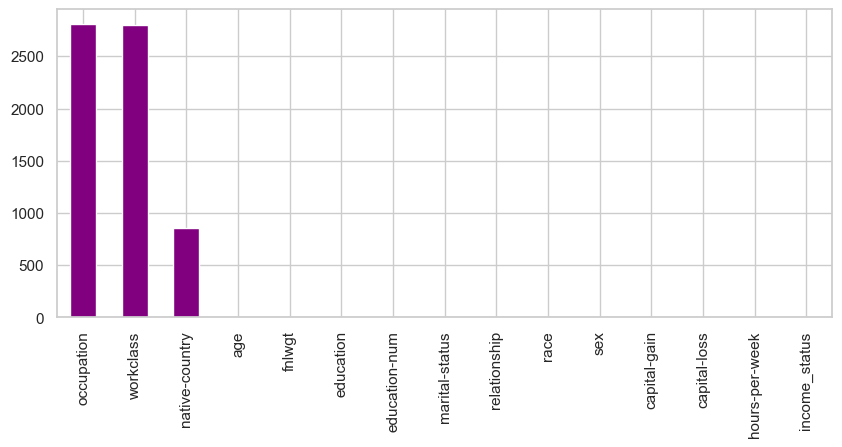

In [23]:
# 11b) Faltantes por columna (grafico)

faltantes = data.isna().sum().sort_values(ascending=False)
plt.figure(figsize=(10, 4))
faltantes.plot(kind="bar", color="purple")
plt.show()


In [24]:
# 12) Matriz de correlacion
cor_mat = data[vars_numericas].corr(numeric_only=True)
cor_mat


,age,fnlwgt,capital-gain,capital-loss,hours-per-week
age,1.000000,-0.076628,0.077229,0.056944,0.071558
fnlwgt,-0.076628,1.000000,-0.003706,-0.004366,-0.013519
capital-gain,0.077229,-0.003706,1.000000,-0.031441,0.082157
capital-loss,0.056944,-0.004366,-0.031441,1.000000,0.054467
hours-per-week,0.071558,-0.013519,0.082157,0.054467,1.000000


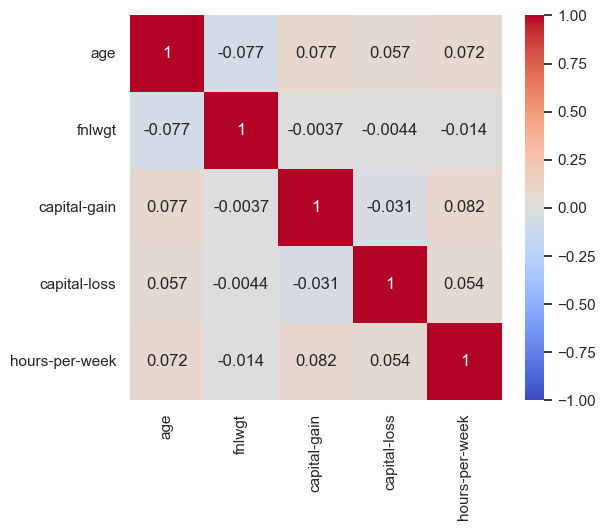

In [88]:
# 12) Heatmap correlacion
plt.figure(figsize=(6, 5))
sns.heatmap(cor_mat, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.show()
